In [ ]:
# Revisiting the "most" important features -- this time using regularisation methods.
#
# Lasso, Ridge, and ElasticNet regression models.

In [1]:
from pandas import DataFrame, read_csv
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load some data for regression

dataset = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.2, random_state=0)

In [3]:
# Problem -- many variables seem related to the outcome. Which features are the "best" ones?

df = DataFrame(data=dataset.data, columns=dataset.feature_names)
df['y'] = dataset.target

corr = abs(df.corr())
corr.style.background_gradient(cmap='coolwarm').format(precision=2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
age,1.00,0.17,0.19,0.34,0.26,0.22,0.08,0.20,0.27,0.30,0.19
sex,0.17,1.00,0.09,0.24,0.04,0.14,0.38,0.33,0.15,0.21,0.04
bmi,0.19,0.09,1.00,0.40,0.25,0.26,0.37,0.41,0.45,0.39,0.59
bp,0.34,0.24,0.40,1.00,0.24,0.19,0.18,0.26,0.39,0.39,0.44
s1,0.26,0.04,0.25,0.24,1.00,0.90,0.05,0.54,0.52,0.33,0.21
s2,0.22,0.14,0.26,0.19,0.90,1.00,0.20,0.66,0.32,0.29,0.17
s3,0.08,0.38,0.37,0.18,0.05,0.20,1.00,0.74,0.40,0.27,0.39
s4,0.20,0.33,0.41,0.26,0.54,0.66,0.74,1.00,0.62,0.42,0.43
s5,0.27,0.15,0.45,0.39,0.52,0.32,0.40,0.62,1.00,0.46,0.57
s6,0.30,0.21,0.39,0.39,0.33,0.29,0.27,0.42,0.46,1.00,0.38


In [4]:
# Baseline model 1 -- linear regression

pipe_regression = Pipeline([
  ('std', RobustScaler()),
  ('linreg', LinearRegression())
])

print("Score: %.3f" % pipe_regression.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_regression.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

DataFrame(abs(pipe_regression['linreg'].coef_), index=dataset.feature_names, columns=['coef'])


Score: 0.332
RMSE: 58.517


,coef
age,2.711891
sex,23.178923
bmi,37.606227
bp,21.033305
s1,40.121310
s2,17.868408
s3,1.457858
s4,12.570364
s5,47.145396
s6,2.673581


In [5]:
# Lasso model -- regularisation with L1 penalty

pipe_lasso = Pipeline([
  ('std', RobustScaler()),
  ('lasso', LassoCV(cv=10))
])

print("Score: %.3f" % pipe_lasso.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_lasso.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

# Best alpha is in: pipe_lasso['lasso'].alpha_
DataFrame(abs(pipe_lasso['lasso'].coef_), index=dataset.feature_names, columns=['coef'])

Score: 0.332
RMSE: 58.542


,coef
age,0.740459
sex,19.818405
bmi,37.784218
bp,18.850046
s1,10.808264
s2,0.000000
s3,13.210076
s4,0.947905
s5,36.742734
s6,2.098771


In [6]:
# Ridge model -- regularisation with L2 penalty

pipe_ridge = Pipeline([
  ('std', RobustScaler()),
  ('ridge', RidgeCV(cv=20))
])

print("Score: %.3f" % pipe_ridge.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_ridge.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

# Best alpha is in: pipe_ridge['ridge'].alpha_
DataFrame(abs(pipe_ridge['ridge'].coef_), index=dataset.feature_names, columns=['coef'])

Score: 0.334
RMSE: 58.457


,coef
age,1.969614
sex,20.070909
bmi,36.633154
bp,19.635694
s1,7.671187
s2,4.718753
s3,12.273689
s4,7.295860
s5,32.751771
s6,3.527339


In [7]:
# ElasticNet model -- regularisation with L1 and L2 penalty terms

pipe_eNet = Pipeline([
  ('std', RobustScaler()),
  ('eNet', ElasticNetCV(cv=20))
])

print("Score: %.3f" % pipe_eNet.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_eNet.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

# Best alpha is in: pipe_eNet['eNet'].alpha_
DataFrame(abs(pipe_eNet['eNet'].coef_), index=dataset.feature_names, columns=['coef'])

Score: 0.335
RMSE: 58.380


,coef
age,1.754201
sex,19.289882
bmi,36.272571
bp,19.304686
s1,6.267001
s2,5.420618
s3,12.762980
s4,6.925503
s5,31.931617
s6,3.626501


In [8]:
# We did not find much coefficients being zero ...
# How does it compare to permutation importance?

# Baseline model 2 -- random forest regression

pipe_rf = Pipeline([
  ('std', RobustScaler()),
  ('rf', RandomForestRegressor())
])

print("Score: %.3f" % pipe_rf.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_rf.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

Score: 0.225
RMSE: 63.050


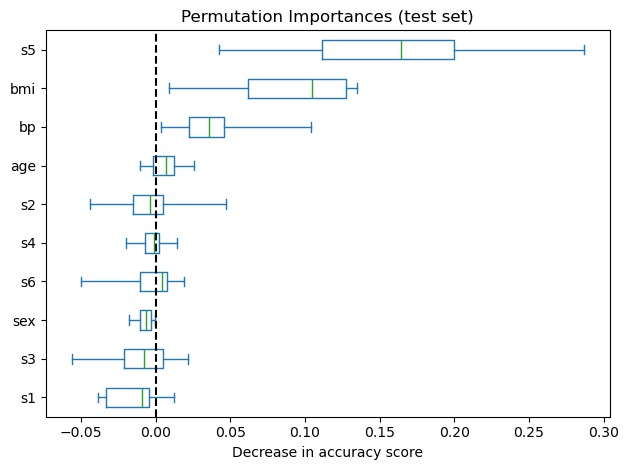

In [9]:
# https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipe_rf, X_test, y_test, n_repeats=10, random_state=0, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=df.columns[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

In [10]:
# let's try a reduced model

X_train, X_test, y_train, y_test = train_test_split(
    df[['s5', 'bmi', 'bp', 'age', 's1']],
    df['y'], test_size=0.2, random_state=0)

print("Score: %.3f" % pipe_rf.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_rf.predict(X_test)
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))


Score: 0.252
RMSE: 61.936


In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

X = dataset.data
Y = dataset.target
features_names = dataset.feature_names

X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_


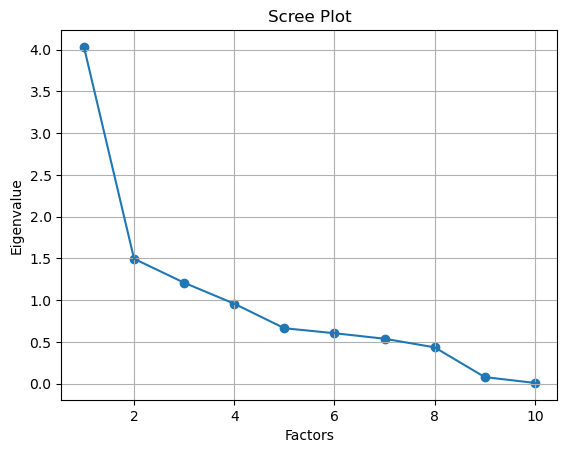

In [27]:
plt.scatter(range(1, len(ev)+1), ev)
plt.plot(range(1, len(ev)+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

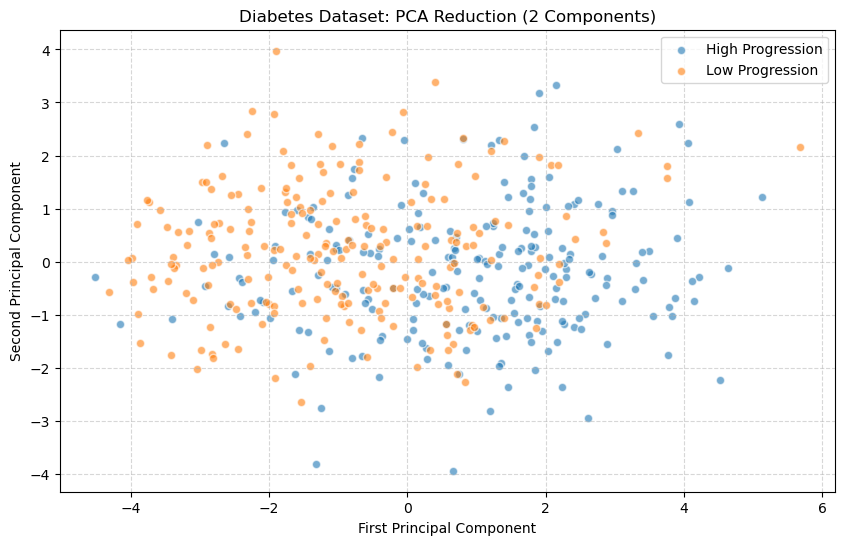

In [32]:
median_progression = pd.Series(Y).median()
y_label = ["High" if val > median_progression else "Low" for val in Y]

# 5. Visualize
plt.figure(figsize=(10, 6))
for label, color in zip(["High", "Low"], ["red", "blue"]):
    indices = [i for i, l in enumerate(y_label) if l == label]
    plt.scatter(X_pca[indices, 0], X_pca[indices, 1], 
                label=f"{label} Progression", alpha=0.6, edgecolors='w')

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Diabetes Dataset: PCA Reduction (2 Components)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()